This notebook contains scripts that calculate everything needed for Fig 4

Files needed:
 - files with drivers (from country, state and city folders, e.g.'country/Delta_SouthKorea_drivers_full_Ranks_RoundedHLA.csv'), 
 - files with all EVs frequencies (from country, state and city folders, e.g. 'country/Delta_country_SouthKorea_Ranks_RoundedHLA.csv').

In [1]:
import numpy as np
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as pltcol
from scipy import stats
import math
from scipy.stats import mannwhitneyu
import glob
from scipy.stats import ttest_ind
import statsmodels.stats.multitest as multi
import cmasher as cmr
#from adjustText import adjust_text

In [2]:
ds_types = ['country', 'state', 'city']
countries = ['UnitedKingdom','Switzerland', 'Netherlands', 'Croatia', 'Poland', 'Romania', 'Norway', 'Sweden', 'Spain', 'Russia','Italy', 'Slovakia', 'Germany',  'Ireland','Austria', 'Portugal','CzechRepublic',  'France', 'Greece','Turkey',  'UnitedArabEmirates', 'SouthKorea', 'Japan', 'Malaysia','Thailand','SriLanka', 'Nigeria', 'Brazil','Colombia', 'Argentina','Chile','Mexico']
thr_list = []
d_tables = dict()
om_tables = dict()
ev_more1mut = 0
for ds_type in ds_types:
    files = glob.glob(ds_type+'/*'+ds_type+'*_Ranks_RoundedHLA.csv')
    names = set([i.split('_')[-3] for i in files])
    for name in names:
        if (name not in d_tables.keys())&(name in countries):
            d_tables[name] = pd.read_csv(ds_type+ '/Delta_' +ds_type +'_'+name+ '_Ranks_RoundedHLA.csv', dtype={'Allele frequency': str}, index_col = False).replace(r'no_freq{1,}', 0, regex=True)
            d_tables[name]['Country'] = name
            d_tables[name]['Allele frequency'] = d_tables[name]['Allele frequency'].astype('float')
            om_tables[name] = pd.read_csv(ds_type+ '/Omicron_' +ds_type +'_'+name+ '_Ranks_RoundedHLA.csv', dtype={'Allele frequency': str}, index_col = False).replace(r'no_freq{1,}', 0, regex=True)
            om_tables[name]['Country'] = name 
            om_tables[name]['Allele frequency'] = om_tables[name]['Allele frequency'].astype('float')            
d_all = pd.concat(list(d_tables.values()))
d_all['Country'] = [''.join([' '+ s if s.isupper()  else s for s in i]).lstrip() for i in d_all['Country']]
d_all['Country'] = d_all['Country'].replace('United Arab Emirates', 'UAE').replace('United Kingdom', 'UK')
d_all_t = d_all[(d_all['mutations'] != 'wt')&(d_all['month'] == 'total')&(~d_all['Allele Name'].str.startswith('HLA-C'))]
om_all = pd.concat(list(om_tables.values()))
om_all['Country'] = [''.join([' '+ s if s.isupper()  else s for s in i]).lstrip() for i in om_all['Country']]
om_all['Country'] = om_all['Country'].replace('United Arab Emirates', 'UAE').replace('United Kingdom', 'UK')
om_all_t = om_all[(om_all['mutations'] != 'wt')&(om_all['month'] == 'total')&(~om_all['Allele Name'].str.startswith('HLA-C'))]
print('d_all_t', d_all_t.shape)
print('om_all_t', om_all_t.shape)

d_tables_drivers = {}
om_tables_drivers = {}
d_tables_drivers_contr = {}
om_tables_drivers_contr = {}

for ds_type in ds_types:
    files = glob.glob(ds_type+'/*'+ds_type+'*_Ranks_RoundedHLA.csv')
    names = set([i.split('_')[-3] for i in files])
    print(names)
    for name in names:
        if (name not in d_tables_drivers.keys())&(name in countries):
            d_tables_drivers[name] = pd.read_csv(ds_type+'/Delta_' + name + '_drivers_full_Ranks_RoundedHLA.csv', dtype={'Allele frequency': str}, index_col = False)
            d_tables_drivers[name]['Country'] = name
            d_tables_drivers[name] = d_tables_drivers[name][~d_tables_drivers[name]['Allele Name'].str.startswith('HLA-C')]
            
            om_tables_drivers[name] = pd.read_csv(ds_type+'/Omicron_' +name + '_drivers_full_Ranks_RoundedHLA.csv', dtype={'Allele frequency': str}, index_col = False)
            om_tables_drivers[name] = om_tables_drivers[name][~om_tables_drivers[name]['Allele Name'].str.startswith('HLA-C')]
            om_tables_drivers[name]['Country'] = name
            d_tables_drivers_contr[name] = pd.read_csv(ds_type+'/Delta_' +name + '_driversCONTRsTRONG15_full_Ranks_RoundedHLA_breakFiltered.csv', dtype={'Allele frequency': str}, index_col = False)
            d_tables_drivers_contr[name] = d_tables_drivers_contr[name][~d_tables_drivers_contr[name]['Allele Name'].str.startswith('HLA-C')]
            d_tables_drivers_contr[name]['Country'] = name
            om_tables_drivers_contr[name] = pd.read_csv(ds_type+'/Omicron_' +name + '_driversCONTRsTRONG15_full_Ranks_RoundedHLA_breakFiltered.csv', dtype={'Allele frequency': str}, index_col = False)        
            om_tables_drivers_contr[name] = om_tables_drivers_contr[name][~om_tables_drivers_contr[name]['Allele Name'].str.startswith('HLA-C')]
            om_tables_drivers_contr[name]['Country'] = name
            
om_all_drivers = pd.concat(om_tables_drivers.values())
om_all_drivers['Country'] = [''.join([' '+ s if s.isupper()  else s for s in i]).lstrip() for i in om_all_drivers['Country']]
om_all_drivers['Country'] = om_all_drivers['Country'].replace('United Arab Emirates', 'UAE').replace('United Kingdom', 'UK')
om_all_drivers['EL_mark'] = 'Lost binding'
d_all_drivers = pd.concat(d_tables_drivers.values())
d_all_drivers['Country'] = [''.join([' '+ s if s.isupper()  else s for s in i]).lstrip() for i in d_all_drivers['Country']]
d_all_drivers['Country'] = d_all_drivers['Country'].replace('United Arab Emirates', 'UAE').replace('United Kingdom', 'UK')
d_all_drivers['EL_mark'] = 'Lost binding'
om_all_drivers_c = pd.concat(om_tables_drivers_contr.values())
om_all_drivers_c['Country'] = [''.join([' '+ s if s.isupper()  else s for s in i]).lstrip() for i in om_all_drivers_c['Country']]
om_all_drivers_c['Country'] = om_all_drivers_c['Country'].replace('United Arab Emirates', 'UAE').replace('United Kingdom', 'UK')
om_all_drivers_c['EL_mark'] = 'Increased binding'
d_all_drivers_c = pd.concat(d_tables_drivers_contr.values())
d_all_drivers_c['Country'] = [''.join([' '+ s if s.isupper()  else s for s in i]).lstrip() for i in d_all_drivers_c['Country']]
d_all_drivers_c['Country'] = d_all_drivers_c['Country'].replace('United Arab Emirates', 'UAE').replace('United Kingdom', 'UK')
d_all_drivers_c['EL_mark'] = 'Increased binding'

print('d_all_drivers_c', d_all_drivers_c.shape)
print('om_all_drivers_c', om_all_drivers_c.shape)

d_all_t (422398, 16)
om_all_t (570976, 16)
{'Sweden', 'UnitedArabEmirates', 'Slovakia', 'Croatia', 'Ireland', 'Thailand', 'France', 'Turkey', 'CzechRepublic', 'Austria', 'Nigeria', 'Greece', 'Portugal', 'Malaysia', 'Poland', 'Romania', 'Germany', 'Italy', 'Norway', 'SouthKorea', 'Japan'}
{'Mexico', 'UnitedKingdom', 'Spain', 'Brazil', 'Russia'}
{'Mexico', 'Sweden', 'SriLanka', 'Switzerland', 'France', 'UnitedKingdom', 'Italy', 'Colombia', 'Brazil', 'Chile', 'Netherlands', 'Portugal', 'Russia', 'Argentina'}
d_all_drivers_c (21044, 27)
om_all_drivers_c (23912, 27)


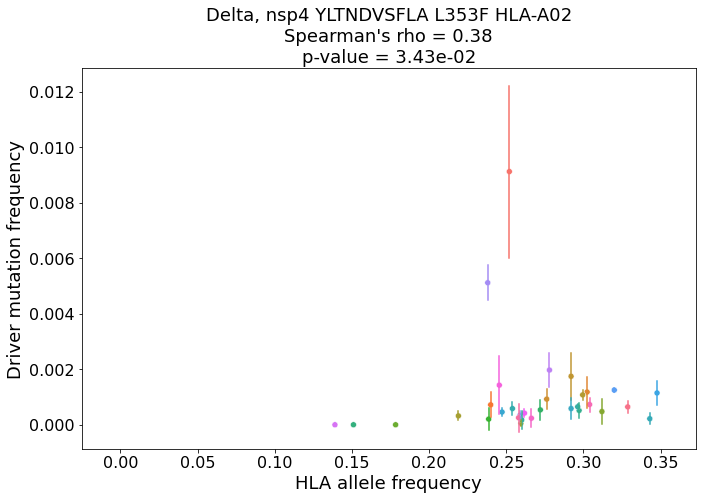

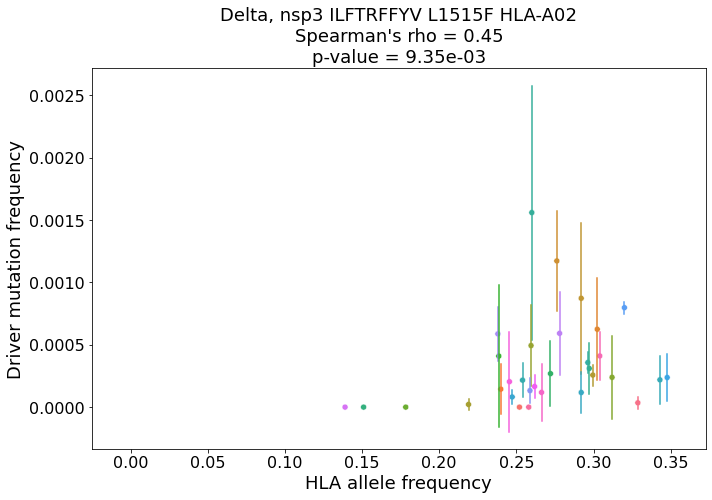

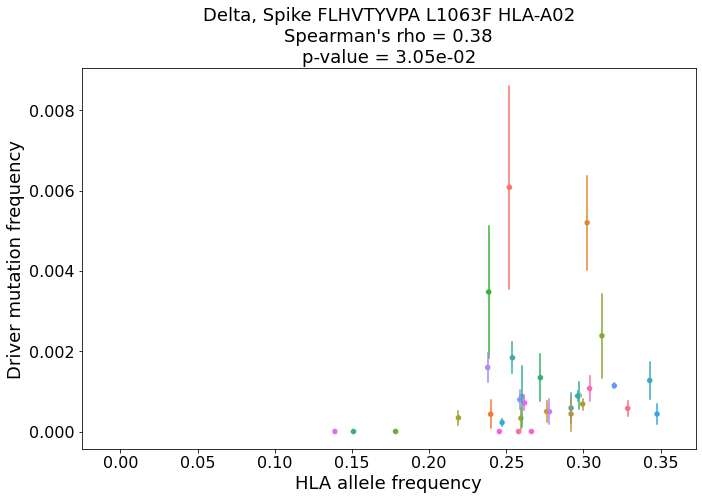

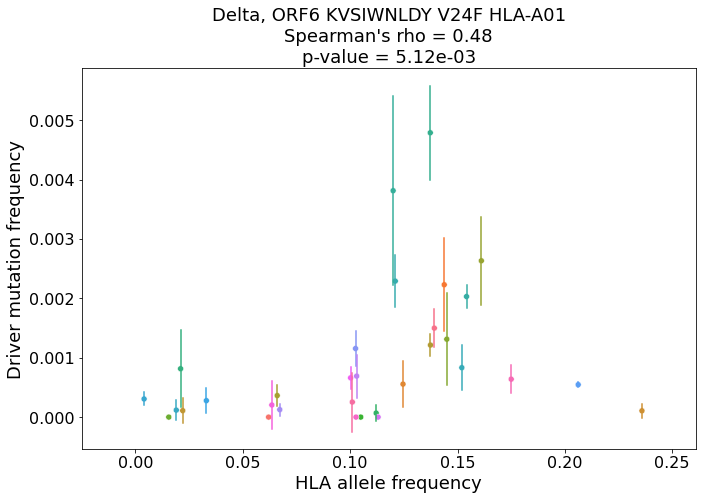

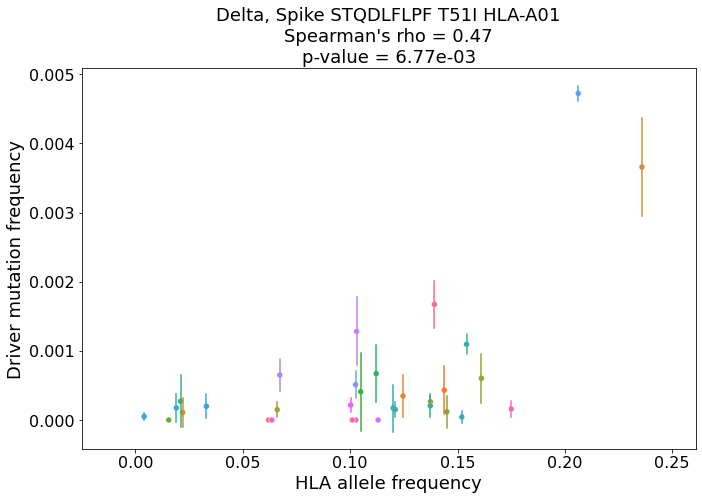

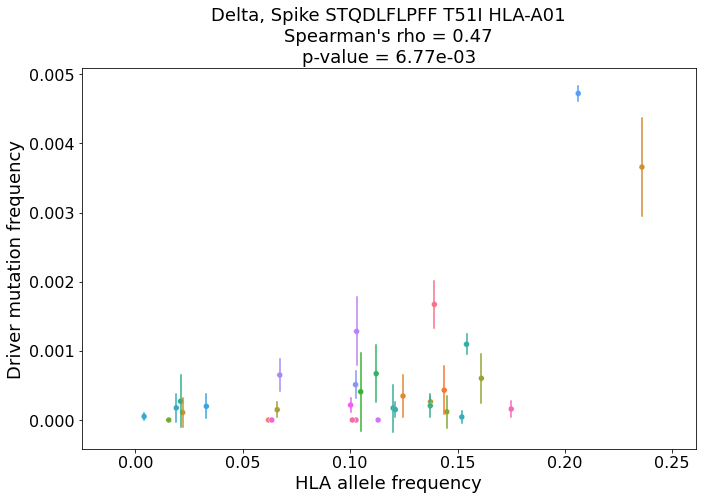

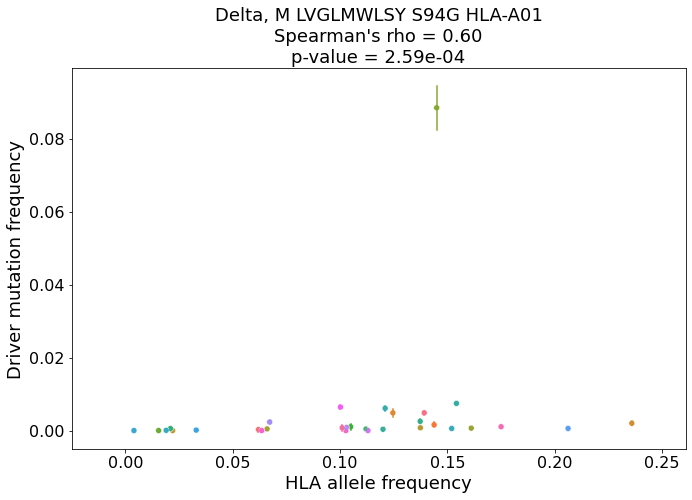

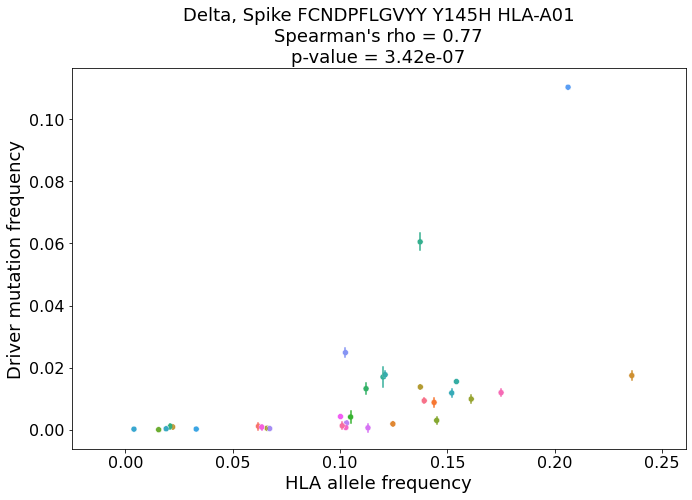

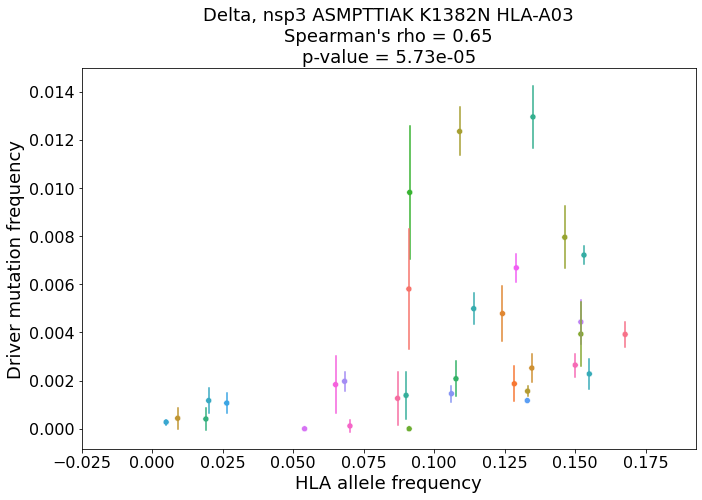

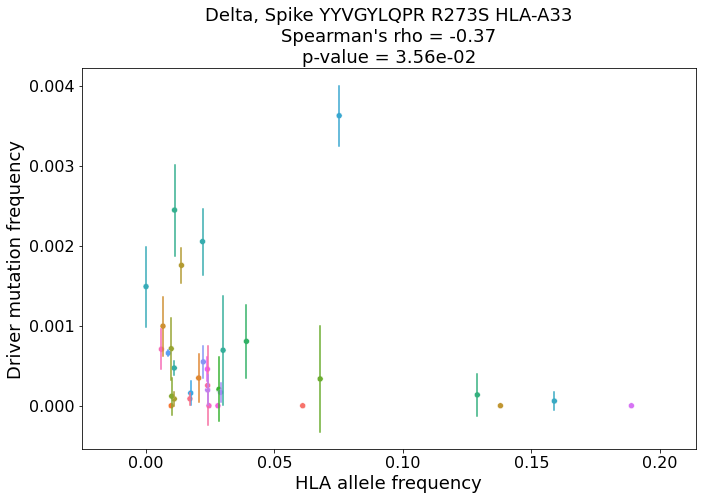

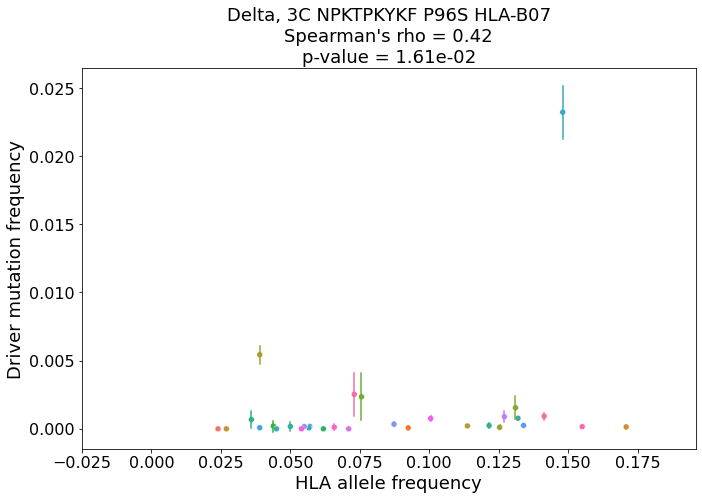

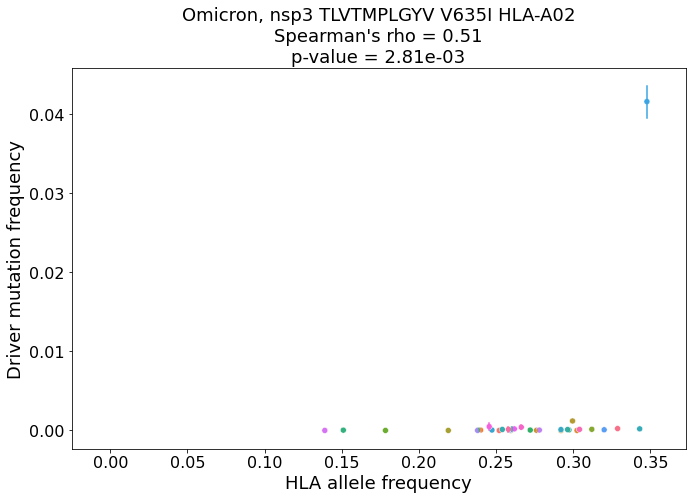

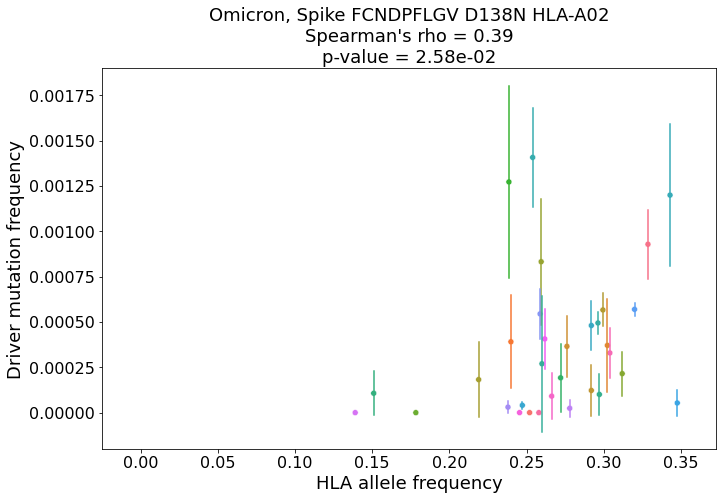

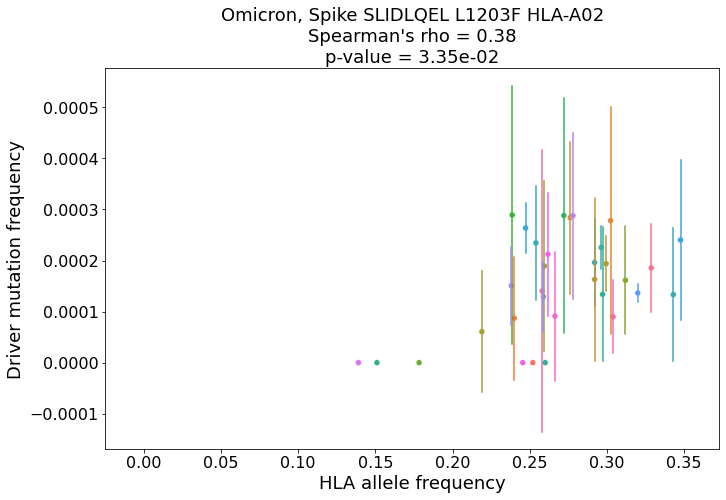

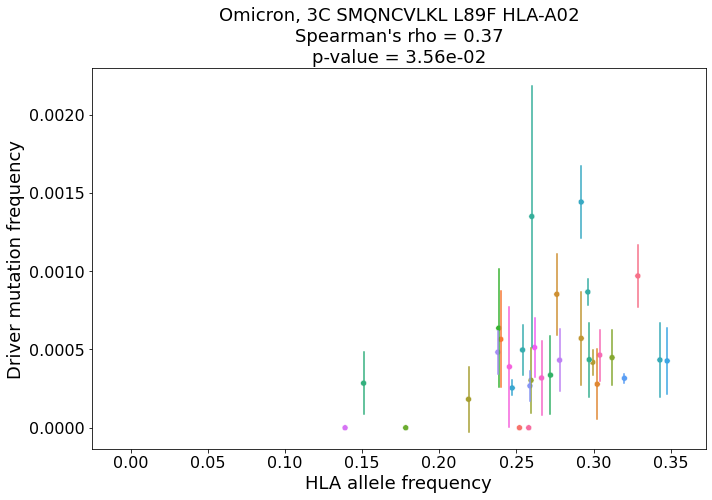

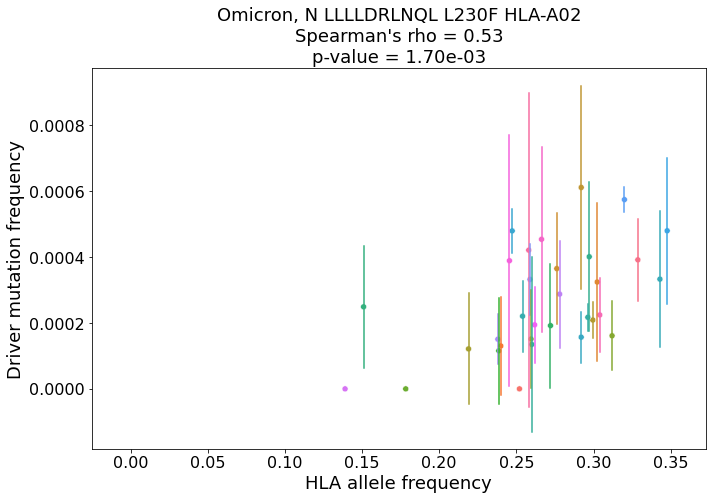

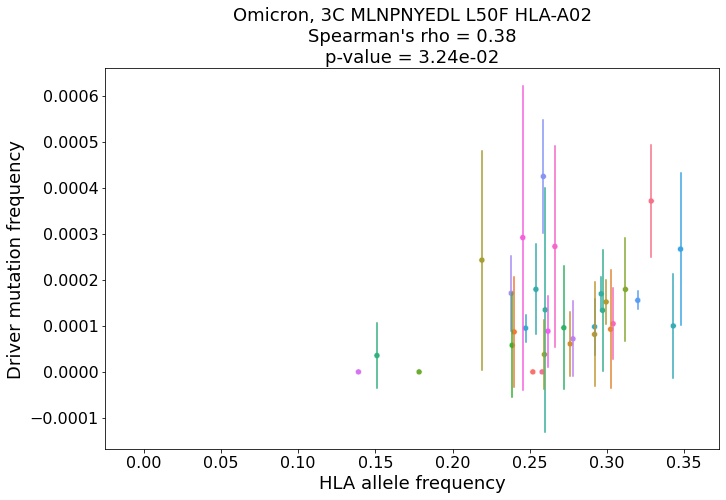

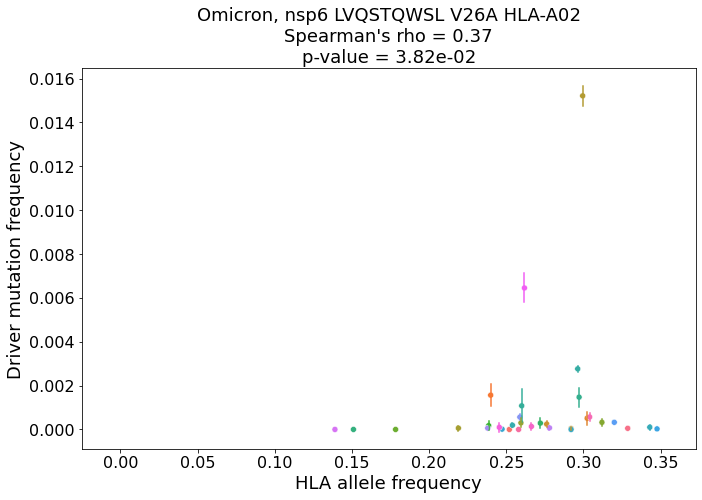

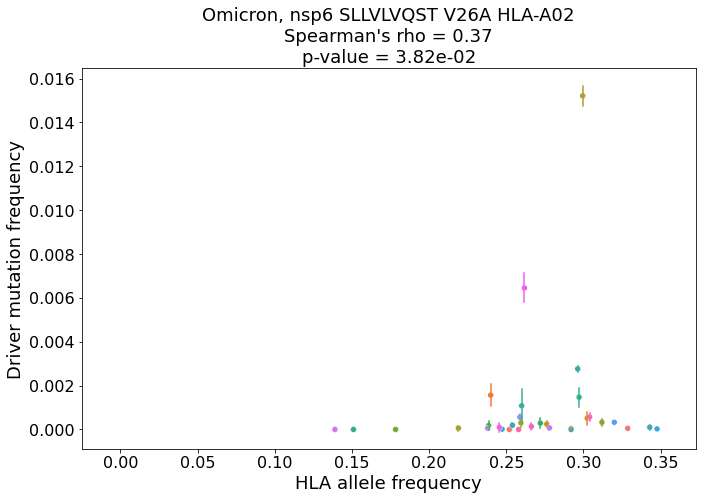

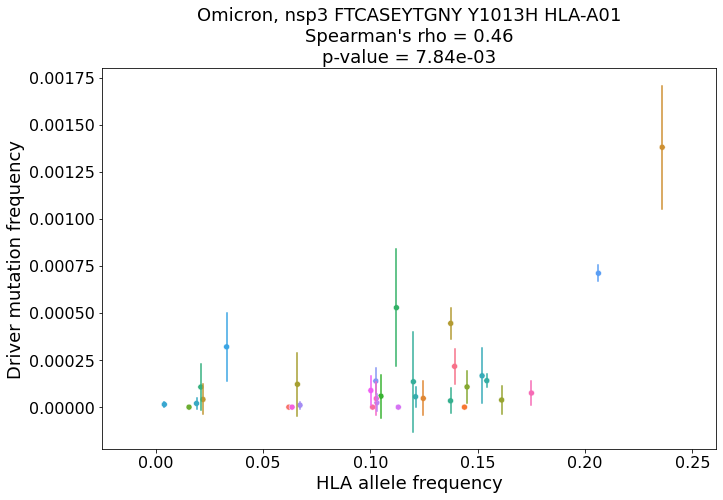

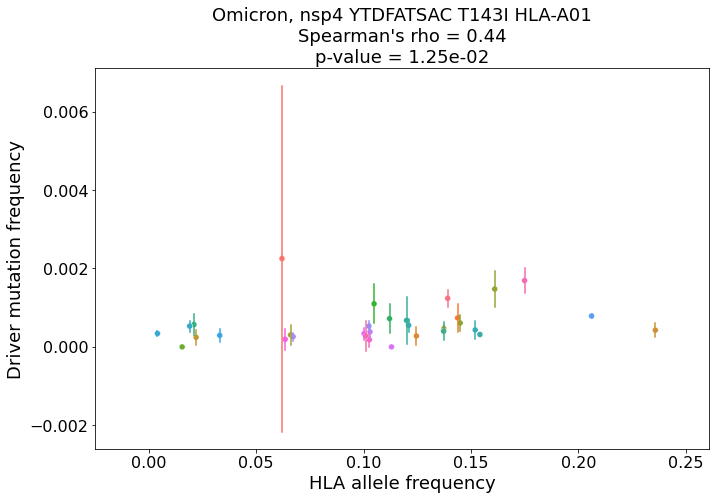

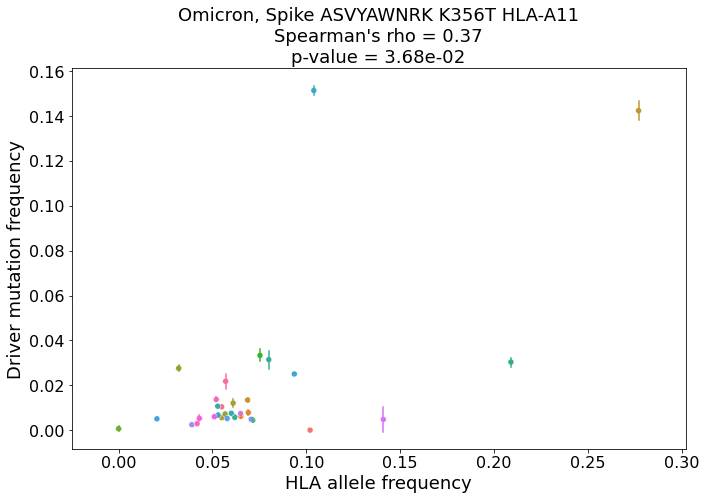

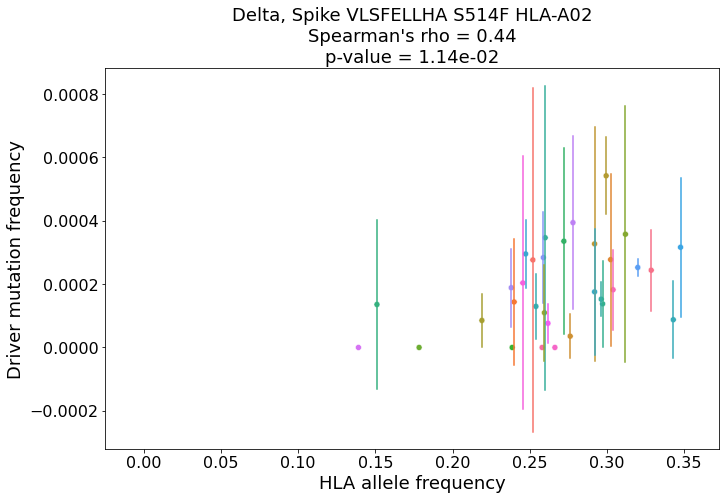

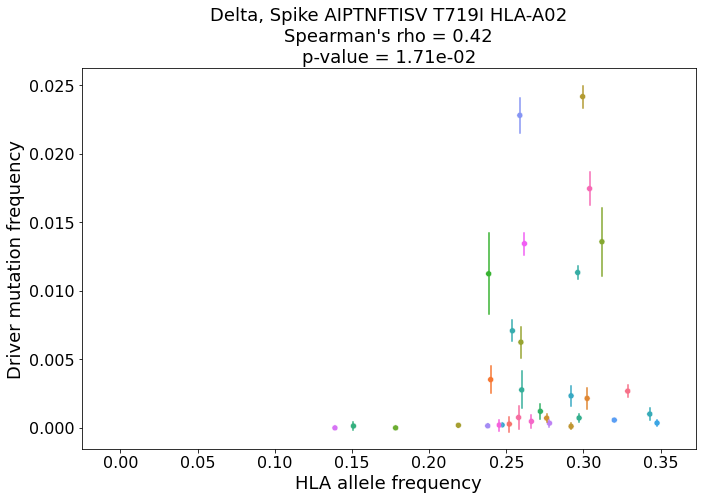

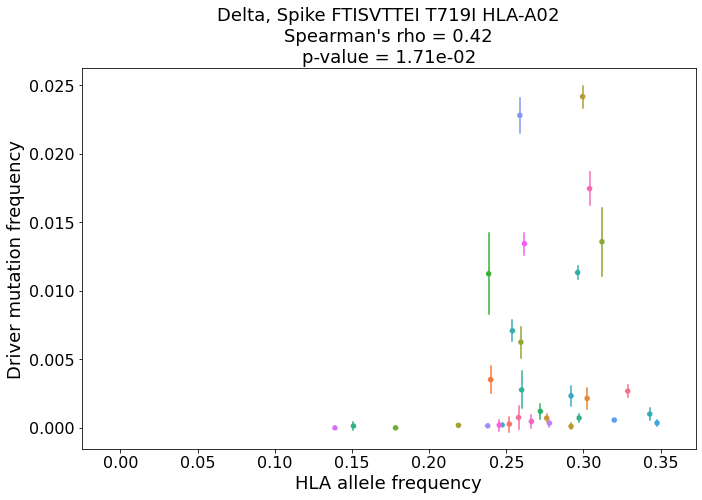

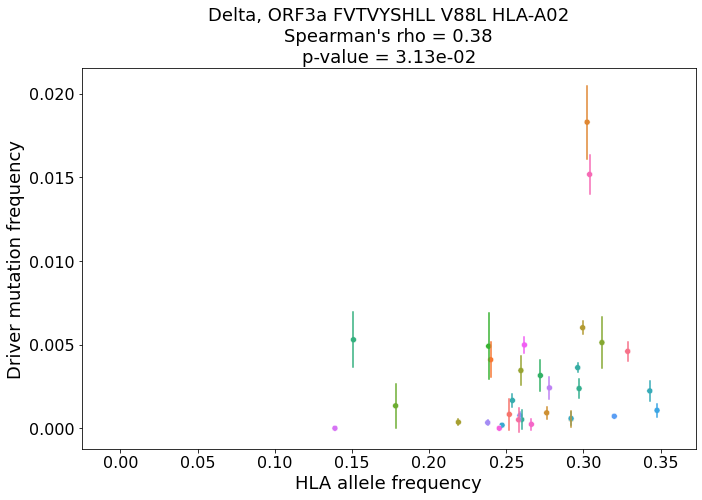

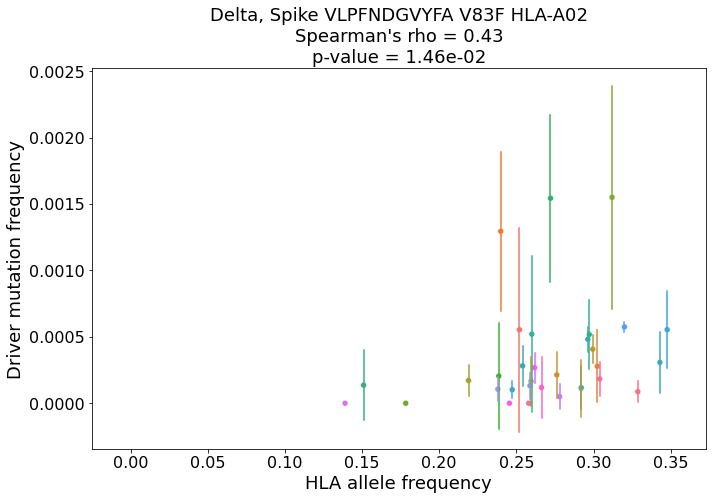

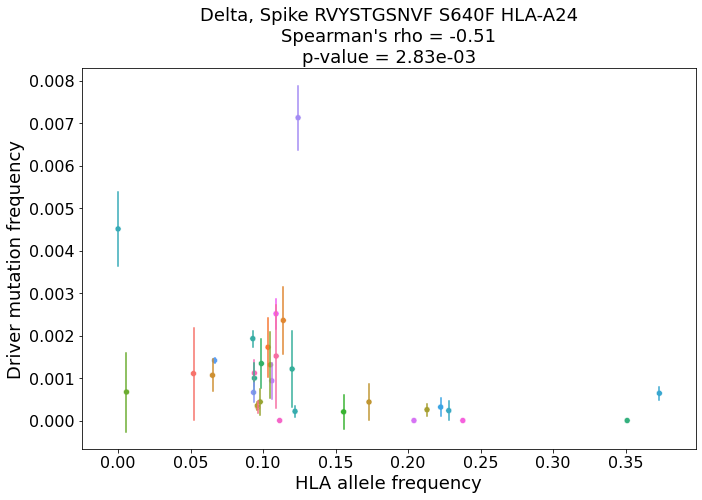

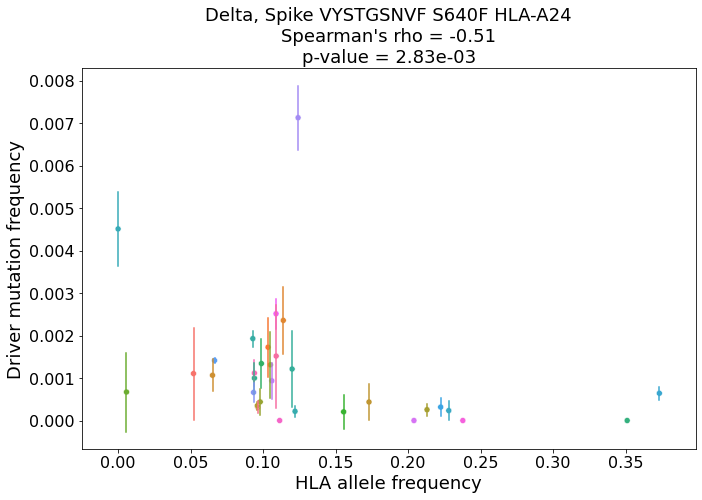

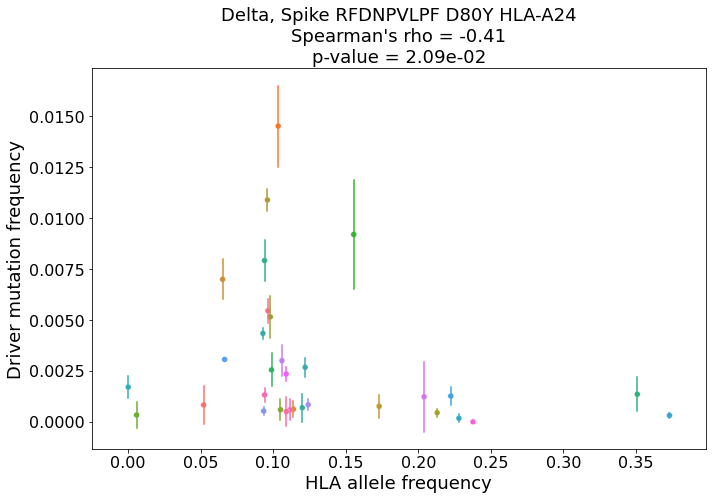

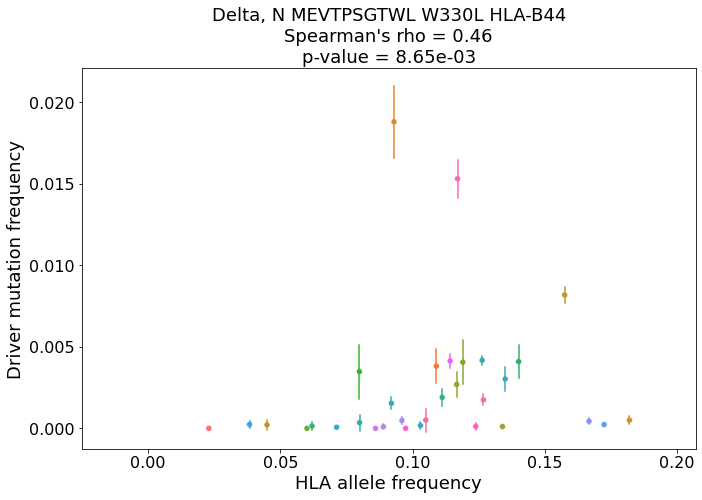

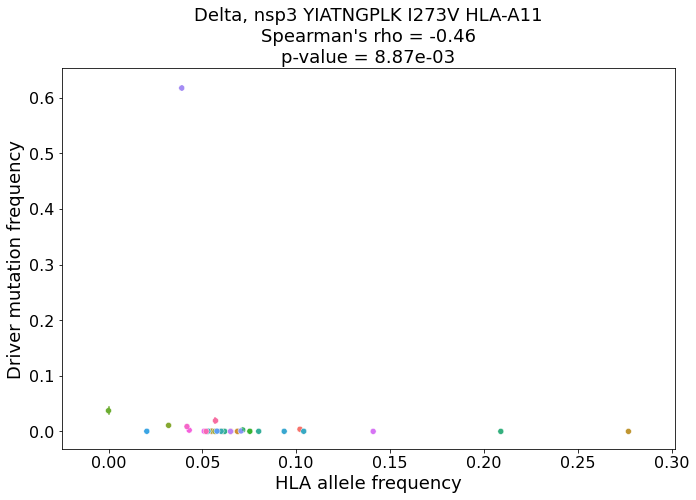

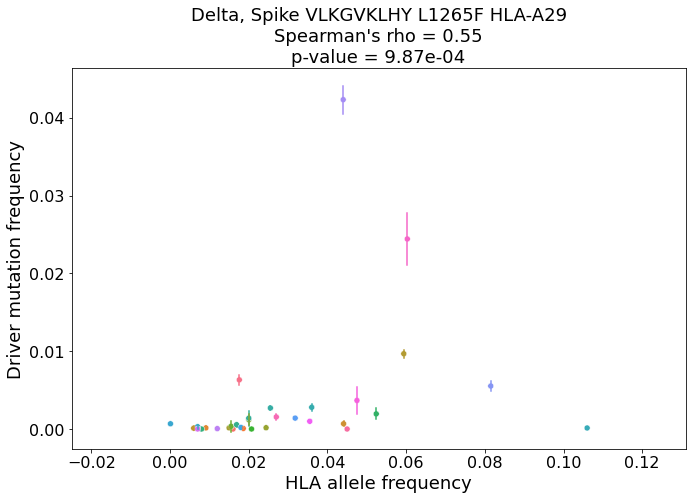

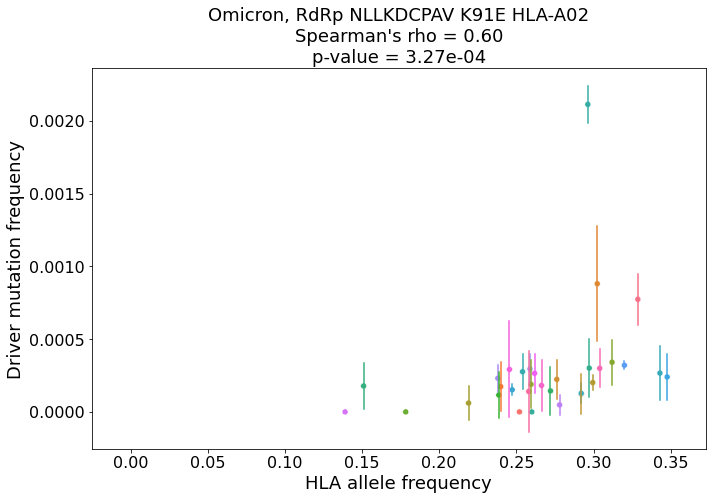

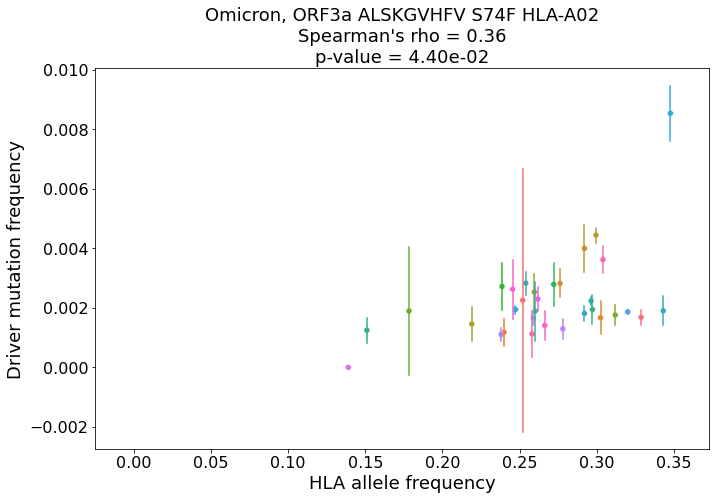

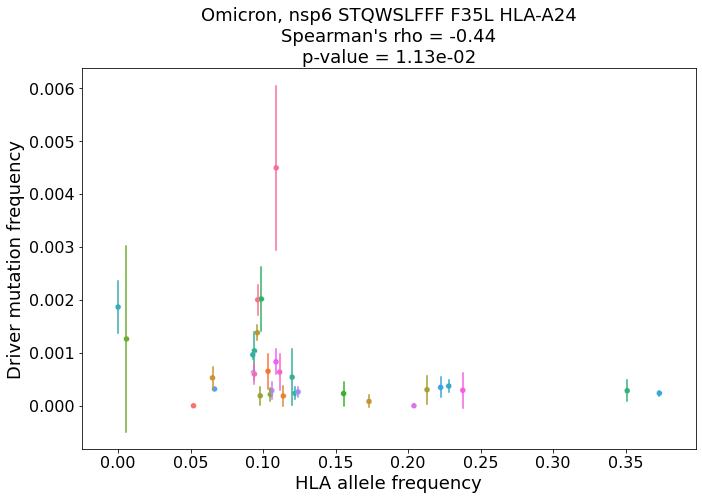

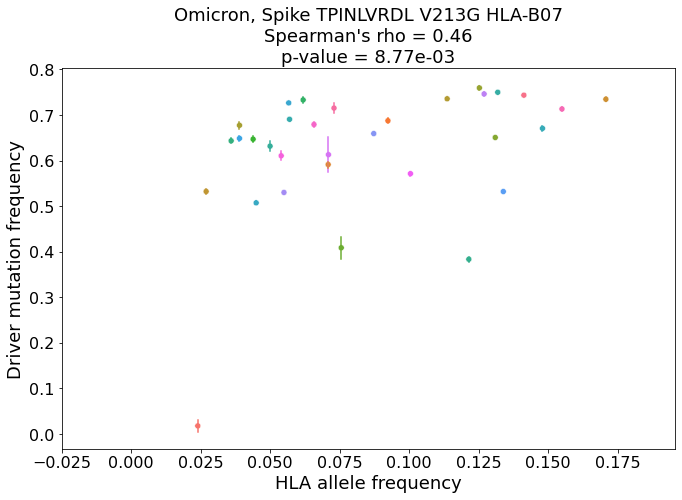

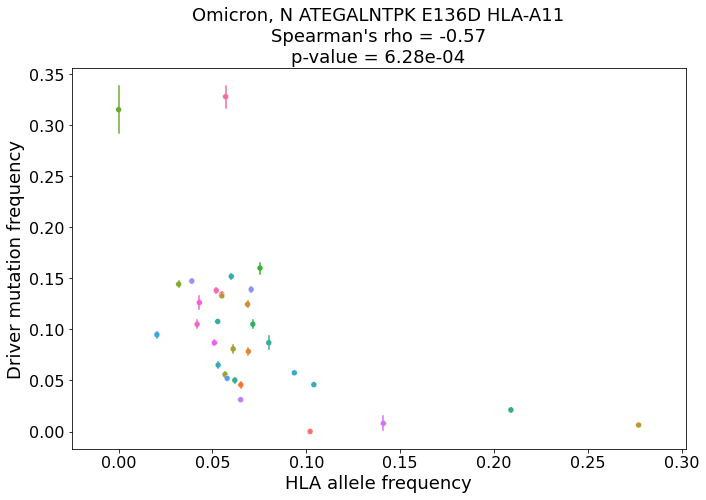

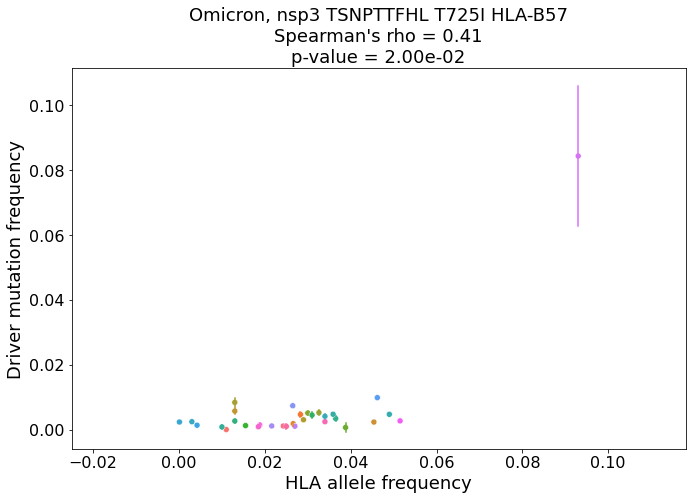

['Delta', 'loss', 10, 1, 82]
['Omicron', 'loss', 11, 0, 95]
['Delta', 'increase', 7, 4, 66]
['Omicron', 'increase', 4, 2, 61]


In [6]:
#if you want to include country absent  HLA:
all_countries_info = d_all_t.drop_duplicates(['Allele Name','Country'])[['Allele Name','Allele frequency', 'Country']].drop_duplicates()
#else:
#all_countries_info = d_all_t[d_all_t['Allele frequency']>0].drop_duplicates(['Allele Name','Country'])[['Allele Name','Allele frequency', 'Country']].drop_duplicates()


drivers_tabs = [d_all_drivers, om_all_drivers]
drivers_tabs_contr = [d_all_drivers_c, om_all_drivers_c]
info = []

for eff, effect_table, el_mark in zip(['loss', 'increase'], [drivers_tabs, drivers_tabs_contr],  ['Lost binding','Increased binding']):
    for strain, strain_driver_table, table_all in zip(['Delta', 'Omicron'], effect_table, [d_all_t,om_all_t]):
        top_drivers = strain_driver_table.groupby(['prot_name', 'peptide', 'Allele Name', 'driver_mut_total', 'muts_with_driver_total', 'driver_fraction_total']).agg({'Country':'size', 'Allele frequency_total':'first', 'fraction_max':'first', 'fraction_total':'first'}).reset_index()
        mut_table = top_drivers[(top_drivers['muts_with_driver_total'] >1)&
                              (top_drivers['driver_fraction_total']>0.9)&
            (~top_drivers['Allele Name'].str.startswith('HLA-C'))
                             ].drop_duplicates(['prot_name', 'peptide', 'Allele Name', 'driver_mut_total'])
        table_all = table_all[table_all['EL_mark'] == el_mark]                
        count_plus = 0
        count_minus = 0
        all_countries = 0
                
        stat_plus = []
        stat_minus = []
        for hla in set(mut_table['Allele Name']):
                muts = list(set(mut_table[(mut_table['Allele Name'] == hla)]['driver_mut_total'].values))
                for mut in muts:
                    for pept in mut_table[(mut_table['Allele Name'] == hla)&(mut_table['driver_mut_total'] == mut)]['peptide'].values: 
                        tab = table_all[(table_all['peptide'] == pept)&(table_all['Allele Name']== hla)&
                            (table_all['mutations'].str.contains(mut))&(table_all['month'] == 'total')].drop_duplicates()
                        tab_freq = tab.groupby(['prot_name', 'peptide', 'Allele Name', 'Country']).agg({
                                'fraction':'sum', 'Allele frequency':'first', 'total_sequences':'first'}).reset_index().drop_duplicates()
                        tab_freq['driver_mut_for_pict'] = mut
                        if (tab_freq.shape[0]>=25):
                            #print(mut, hla, pept)
                            tab_freq = pd.merge(all_countries_info[all_countries_info['Allele Name'] == hla], tab_freq, on = ['Country', 'Allele Name'], how = 'left').fillna(0)
                            #if you do not want to inclide country absent mutations:                       
                            #tab_freq = tab_freq[tab_freq['fraction']>0]
                            tab_freq = tab_freq.rename(columns = {'Allele frequency_x':'Allele frequency'}).drop_duplicates()
                            rho, pval = stats.spearmanr(tab_freq['Allele frequency'],tab_freq['fraction'])
                            all_countries +=1

                            if (pval<=0.05):
                                fig, ax = plt.subplots(figsize = (11,7))
                                colors = dict(zip(tab_freq['Country'], sns.color_palette("husl", tab_freq.shape[0])))
                                g = sns.scatterplot(data=tab_freq, x='Allele frequency', y='fraction', hue='Country', ax=ax, palette = sns.color_palette("husl", tab_freq.shape[0]), 
                                                           hue_order = tab_freq['Country'], legend=False)
                                texts = []
                                prev_al = 10
                                prev_frac = 10
                                for index, row in tab_freq.sort_values(['fraction', 'Allele frequency'], ascending = False).iterrows():
                                    #al_dif = abs(prev_al - row['Allele frequency'])
                                    #frac_dif = abs(prev_frac - row['fraction'])
                                    #if (al_dif>0.03)|(frac_dif>0.0005):
                                    #    texts.append(plt.text(row['Allele frequency'], row['fraction'], row['Country'], color = colors[row['Country']], fontsize = 16))
                                    #prev_al = row['Allele frequency']
                                    #prev_frac = row['fraction']
                                    #print(row['Allele frequency'], row['fraction'], row['Country'], colors[row['Country']])
                                    if row['fraction']!=0:
                                        ax.plot([row['Allele frequency'], row['Allele frequency']], [row['fraction'] - 1.96*(row['fraction']*(1-row['fraction'])/row['total_sequences'])**0.5, 
                                                row['fraction'] + 1.96*(row['fraction']*(1-row['fraction'])/row['total_sequences'])**0.5], 
                                                color = colors[row['Country']])  
                                ax.set_xlim(-0.025, 0.025+tab_freq['Allele frequency'].max())
                                ax.set_title(strain + ', ' + tab['prot_name'].values[0] + ' '+pept + ' '+mut + ' ' + hla + '\n' + 'Spearman\'s '+ 'rho = ' + f'{rho:.02f}'  + '\n' + 'p-value = ' + f'{pval:.02e}',
                                             fontsize = 18)
                                nlabels = len(ax.texts)
                                #adjust_text(texts, only_move={'texts':'xy'}, force_text = (0.4,4),arrowprops=dict(arrowstyle="->", color='gray', lw=0.5))
                                #for new, old in zip(ax.texts[nlabels:], ax.texts):
                                #    new.arrow_patch.set_color(old.get_color())
                                ax.set_xlabel('HLA allele frequency'  , fontsize = 18)
                                ax.set_ylabel('Driver mutation frequency'  , fontsize = 18)
                                ax.tick_params(axis = 'both', labelsize=16)
                                plt.show()
                                #plt.savefig('geogr_corrs/top_'+eff+'_total/'+strain+'_' +mut +'_HLAZeros.jpg', dpi=300, bbox_inches='tight')

                                if rho >0:
                                    count_plus +=1
                                else:
                                    count_minus+=1
        info.append([strain, eff, count_plus, count_minus, all_countries])
for i in info:
    print(i)

In [ ]:
#for permutations
ds_types = ['country', 'state', 'city']
countries = ['UnitedKingdom','Switzerland', 'Netherlands', 'Croatia', 'Poland', 'Romania', 'Norway', 'Sweden', 'Spain', 'Russia','Italy', 'Slovakia', 'Germany',  'Ireland','Austria', 'Portugal','CzechRepublic',  'France', 'Greece','Turkey',  'UnitedArabEmirates', 'SouthKorea', 'Japan', 'Malaysia','Thailand','SriLanka', 'Nigeria', 'Brazil','Colombia', 'Argentina','Chile','Mexico']
thr_list = []
d_tables = dict()
om_tables = dict()
ev_more1mut = 0
for ds_type in ds_types:
    files = glob.glob(ds_type+'/*'+ds_type+'*_Ranks_RoundedHLA.csv')
    names = set([i.split('_')[-3] for i in files])
    for name in names:
        if (name not in d_tables.keys())&(name in countries):
            d_tables[name] = pd.read_csv(ds_type+ '/Delta_' +ds_type +'_'+name+ '_Ranks_RoundedHLA.csv', dtype={'Allele frequency': str}, index_col = False).replace(r'no_freq{1,}', 0, regex=True)
            d_tables[name]['Country'] = name
            d_tables[name]['Allele frequency'] = d_tables[name]['Allele frequency'].astype('float')
            om_tables[name] = pd.read_csv(ds_type+ '/Omicron_' +ds_type +'_'+name+ '_Ranks_RoundedHLA.csv', dtype={'Allele frequency': str}, index_col = False).replace(r'no_freq{1,}', 0, regex=True)
            om_tables[name]['Country'] = name 
            om_tables[name]['Allele frequency'] = om_tables[name]['Allele frequency'].astype('float')            
d_all = pd.concat(list(d_tables.values()))
d_all['Country'] = [''.join([' '+ s if s.isupper()  else s for s in i]).lstrip() for i in d_all['Country']]
d_all['Country'] = d_all['Country'].replace('United Arab Emirates', 'UAE').replace('United Kingdom', 'UK')
d_all_t = d_all[(d_all['mutations'] != 'wt')&(d_all['month'] == 'total')&(~d_all['Allele Name'].str.startswith('HLA-C'))]
om_all = pd.concat(list(om_tables.values()))
om_all['Country'] = [''.join([' '+ s if s.isupper()  else s for s in i]).lstrip() for i in om_all['Country']]
om_all['Country'] = om_all['Country'].replace('United Arab Emirates', 'UAE').replace('United Kingdom', 'UK')
om_all_t = om_all[(om_all['mutations'] != 'wt')&(om_all['month'] == 'total')&(~om_all['Allele Name'].str.startswith('HLA-C'))]


d_tables_drivers = {}
om_tables_drivers = {}
d_tables_drivers_contr = {}
om_tables_drivers_contr = {}

for ds_type in ds_types:
    files = glob.glob(ds_type+'/*'+ds_type+'*_Ranks_RoundedHLA.csv')
    names = set([i.split('_')[-3] for i in files])
    #print(names)
    for name in names:
        if (name not in d_tables_drivers.keys())&(name in countries):
            d_tables_drivers[name] = pd.read_csv(ds_type+'/Delta_' + name + '_drivers_full_Ranks_RoundedHLA.csv', dtype={'Allele frequency': str}, index_col = False)
            d_tables_drivers[name]['Country'] = name
            d_tables_drivers[name] = d_tables_drivers[name][~d_tables_drivers[name]['Allele Name'].str.startswith('HLA-C')]
            om_tables_drivers[name] = pd.read_csv(ds_type+'/Omicron_' +name + '_drivers_full_Ranks_RoundedHLA.csv', dtype={'Allele frequency': str}, index_col = False)
            om_tables_drivers[name] = om_tables_drivers[name][~om_tables_drivers[name]['Allele Name'].str.startswith('HLA-C')]
            om_tables_drivers[name]['Country'] = name
            d_tables_drivers_contr[name] = pd.read_csv(ds_type+'/Delta_' +name + '_driversCONTRsTRONG15_full_Ranks_RoundedHLA_breakFiltered.csv', dtype={'Allele frequency': str}, index_col = False)
            d_tables_drivers_contr[name] = d_tables_drivers_contr[name][~d_tables_drivers_contr[name]['Allele Name'].str.startswith('HLA-C')]
            d_tables_drivers_contr[name]['Country'] = name
            om_tables_drivers_contr[name] = pd.read_csv(ds_type+'/Omicron_' +name + '_driversCONTRsTRONG15_full_Ranks_RoundedHLA_breakFiltered.csv', dtype={'Allele frequency': str}, index_col = False)        
            om_tables_drivers_contr[name] = om_tables_drivers_contr[name][~om_tables_drivers_contr[name]['Allele Name'].str.startswith('HLA-C')]
            om_tables_drivers_contr[name]['Country'] = name
om_all_drivers = pd.concat([om_tables_drivers[i] for i in om_tables_drivers.keys()])
om_all_drivers['Country'] = [''.join([' '+ s if s.isupper()  else s for s in i]).lstrip() for i in om_all_drivers['Country']]
om_all_drivers['Country'] = om_all_drivers['Country'].replace('United Arab Emirates', 'UAE').replace('United Kingdom', 'UK')
om_all_drivers['EL_mark'] = 'Lost binding'
d_all_drivers = pd.concat([d_tables_drivers[i] for i in d_tables_drivers.keys()])
d_all_drivers['Country'] = [''.join([' '+ s if s.isupper()  else s for s in i]).lstrip() for i in d_all_drivers['Country']]
d_all_drivers['Country'] = d_all_drivers['Country'].replace('United Arab Emirates', 'UAE').replace('United Kingdom', 'UK')
d_all_drivers['EL_mark'] = 'Lost binding'
d_all_drivers['mut_occurrences_total'] = [int(str(i).split('_')[0]) for i in d_all_drivers['mut_occurrences_total']]
om_all_drivers_c = pd.concat([d_tables_drivers_contr[i] for i in d_tables_drivers_contr.keys()])
om_all_drivers_c['Country'] = [''.join([' '+ s if s.isupper()  else s for s in i]).lstrip() for i in om_all_drivers_c['Country']]
om_all_drivers_c['Country'] = om_all_drivers_c['Country'].replace('United Arab Emirates', 'UAE').replace('United Kingdom', 'UK')
om_all_drivers_c['EL_mark'] = 'Increased binding'
d_all_drivers_c = pd.concat([d_tables_drivers_contr[i] for i in d_tables_drivers_contr.keys()])
d_all_drivers_c['Country'] = [''.join([' '+ s if s.isupper()  else s for s in i]).lstrip() for i in d_all_drivers_c['Country']]
d_all_drivers_c['Country'] = d_all_drivers_c['Country'].replace('United Arab Emirates', 'UAE').replace('United Kingdom', 'UK')
d_all_drivers_c['EL_mark'] = 'Increased binding'
d_all_drivers_c['mut_occurrences_total'] = [int(str(i).split('_')[0]) for i in d_all_drivers_c['mut_occurrences_total']]

all_countries_info = d_all_t.drop_duplicates(['Allele Name','Country'])[['Allele Name','Allele frequency', 'Country']].drop_duplicates()
drivers_tabs = [d_all_drivers, om_all_drivers]
drivers_tabs_contr = [d_all_drivers_c, om_all_drivers_c]

for eff, effect_table, el_mark in zip(['loss', 'increase'], [drivers_tabs, drivers_tabs_contr],  ['Lost binding','Increased binding']):
    for strain, strain_driver_table, table_all in zip(['Delta', 'Omicron'], effect_table, [d_all_t,om_all_t]):
        mut_table = strain_driver_table.groupby(['prot_name', 'peptide', 'Allele Name', 'driver_mut_total', 'muts_with_driver_total', 'driver_fraction_total']).agg({'Country':'size', 'Allele frequency_total':'first', 'fraction_max':'first', 'fraction_total':'first'}).reset_index()
        mut_table = mut_table[(mut_table['muts_with_driver_total'] >1)&
                              (mut_table['driver_fraction_total']>0.9)].drop_duplicates(['prot_name', 'peptide', 'Allele Name', 'driver_mut_total'])

        table_all = table_all[table_all['EL_mark'] == el_mark]                
        count_plus = 0
        count_minus = 0
        all_countries = 0
                
        stat_plus = []
        stat_minus = []
        for i in range(100):
            count_plus = 0
            count_minus = 0
            for hla in set(mut_table['Allele Name']):
                muts = list(set(mut_table[(mut_table['Allele Name'] == hla)]['driver_mut_total'].values))
                #print(hlas)
                    
                pvs = [i + '_pv' for i in muts]
                for mut in muts:
                    for pept in mut_table[(mut_table['Allele Name'] == hla)&(mut_table['driver_mut_total'] == mut)]['peptide'].values: 
                        tab = table_all[(table_all['peptide'] == pept)&(table_all['Allele Name']== hla)&
                            (table_all['mutations'].str.contains(mut))&(table_all['month'] == 'total')].drop_duplicates()
                        tab_freq = tab.groupby(['prot_name', 'peptide', 'Allele Name', 'Country']).agg({
                                'fraction':'sum', 'Allele frequency':'first'}).reset_index().drop_duplicates()
                        tab_freq['driver_mut_for_pict'] = mut
                        if (tab_freq.shape[0]>=25):
                            #print(mut, hla, pept)
                            tab_freq = pd.merge(all_countries_info[all_countries_info['Allele Name'] == hla], tab_freq, on = ['Country', 'Allele Name'], how = 'left').fillna(0)
                            #!!!                            
                            #tab_freq = tab_freq[tab_freq['fraction']>0]
                            #PERMUTATIONS
                            tab_freq['Allele frequency_random'] = np.random.permutation(tab_freq['Allele frequency_x'].values)
                            #PERMUTATIONS
                            rho, pval = stats.spearmanr(tab_freq['Allele frequency_random'],tab_freq['fraction'])     
                            if (pval<=0.05):                                
                                if rho >0:
                                    count_plus +=1
                                else:
                                    count_minus+=1
            stat_plus.append(count_plus)
            stat_minus.append(count_minus)
        df = pd.DataFrame({'num':[i for i in range(100)], 'plus':stat_plus, 'minus':stat_minus})
        df.to_csv('Fig4/all_' + strain + '_' + eff + '_permutation100_allZeros.csv', index = False)

(30, 9)
(31, 9)
HLA-A01 0.7650293255131965 3.415092240928987e-07
(31, 10)
10    Nigeria
Name: Country, dtype: object
HLA-A01 0.7650293255131965 3.415092240928987e-07
(31, 10)
10    Nigeria
Name: Country, dtype: object


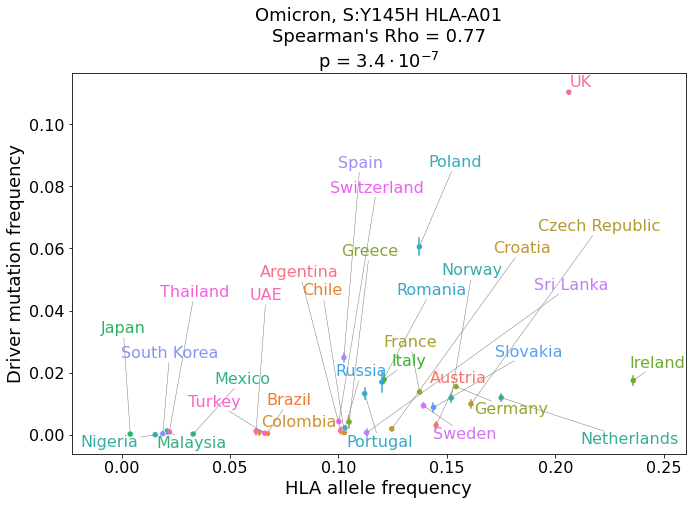

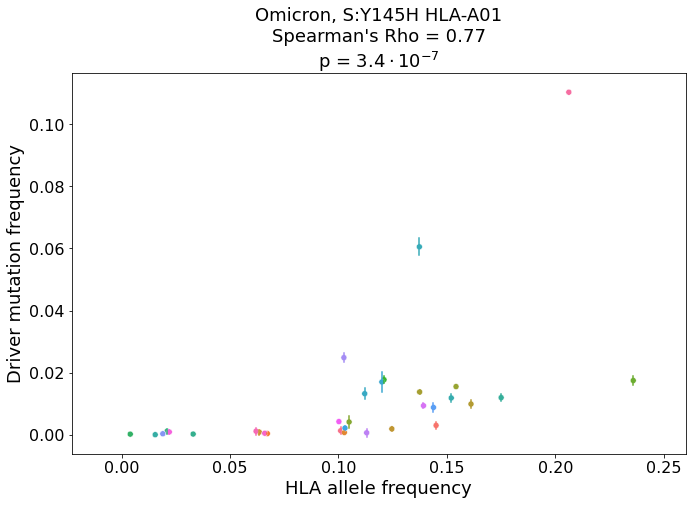

(29, 9)
(30, 9)
HLA-A03 0.64967919340055 5.7284001669382354e-05
(30, 10)
10      Nigeria
26    Sri Lanka
Name: Country, dtype: object
HLA-A03 0.64967919340055 5.7284001669382354e-05
(30, 10)
10      Nigeria
26    Sri Lanka
Name: Country, dtype: object


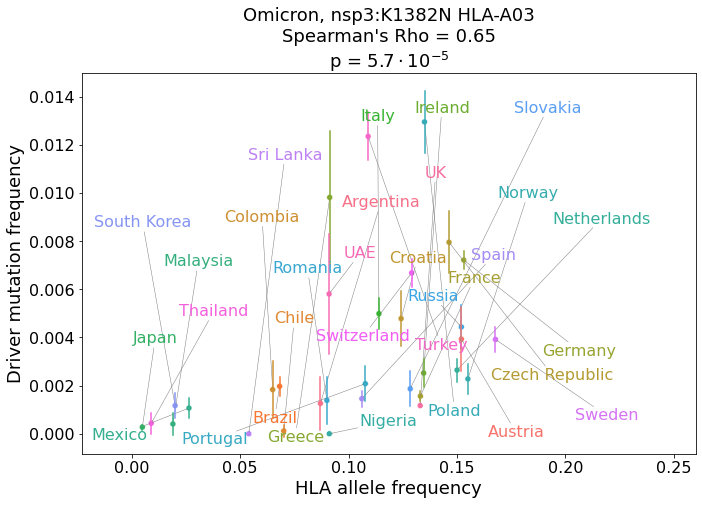

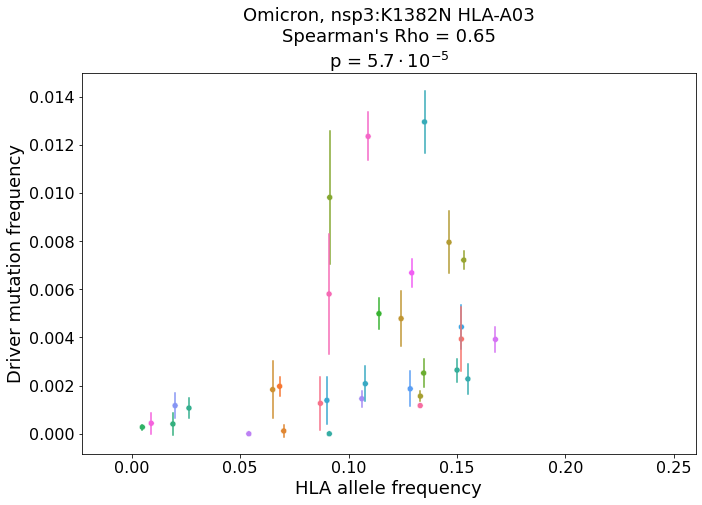

In [29]:
#for fig. 4a
from adjustText import adjust_text
from math import floor, log10
def sci_notation(num, decimal_digits=1, precision=None, exponent=None):
    """
    Returns a string representation of the scientific
    notation of the given number formatted for use with
    LaTeX or Mathtext, with specified number of significant
    decimal digits and precision (number of decimal digits
    to show). The exponent to be used can also be specified
    explicitly.
    """
    if exponent is None:
        exponent = int(floor(log10(abs(num))))
    coeff = round(num / float(10**exponent), decimal_digits)
    if precision is None:
        precision = decimal_digits

    return r"${0:.{2}f}\cdot10^{{{1:d}}}$".format(coeff, exponent, precision)


d_all_t = d_all_t[d_all_t['Allele frequency']>0]
d_top_drivers = d_all_drivers.groupby(['prot_name', 'peptide', 'Allele Name', 'driver_mut_total', 'muts_with_driver_total', 'driver_fraction_total']).agg({'Country':'size', 'Allele frequency_total':'first', 'fraction_max':'first', 'fraction_total':'first'}).reset_index()
d_top_drivers = d_top_drivers[(d_top_drivers['muts_with_driver_total'] >1)&
                              (d_top_drivers['driver_fraction_total']>0.9)&
    (~d_top_drivers['Allele Name'].str.startswith('HLA-C'))].drop_duplicates(['prot_name', 'peptide', 'Allele Name', 'driver_mut_total'])
d_top_drivers['prot_mut'] = d_top_drivers['prot_name'] +'_'+ d_top_drivers['driver_mut_total']

all_countries_info = d_all_t.drop_duplicates(['Allele Name','Country'])[['Allele Name','Allele frequency', 'Country']].drop_duplicates()

top_drivers = d_top_drivers.copy()
mut_table = top_drivers.drop_duplicates(['driver_mut_total', 'Allele Name', 'peptide'])
table_all = d_all_t.copy()
table_all['Allele frequency'] = [i if j == 'Lost binding' else 0 for i, j in zip(table_all['Allele frequency'], table_all['EL_mark'])]


mut_table = mut_table[(mut_table['driver_mut_total'] == 'K1382N')|(mut_table['driver_mut_total'] == 'Y145H')]

for hla in set(mut_table['Allele Name']):
    table_with_muts = mut_table.copy()
    muts = list(set(table_with_muts[(table_with_muts['Allele Name'] == hla)]['driver_mut_total'].values))
    for mut in muts:
        for pept in mut_table[(mut_table['Allele Name'] == hla)&(mut_table['driver_mut_total'] == mut)]['peptide'].values: 
            tab = table_all[(table_all['peptide'] == pept)&(table_all['Allele Name']== hla)&
                (table_all['mutations'].str.contains(mut))&(table_all['month'] == 'total')].drop_duplicates()
            tab_freq = tab.groupby(['prot_name', 'peptide', 'Allele Name', 'Country']).agg({
                    'fraction':'sum', 'Allele frequency':'first', 'mutations':('_').join, 'total_sequences':'first'}).reset_index().drop_duplicates()
            #print(tab_freq.shape)
            tab_freq['driver_mut_for_pict'] = mut
            print(tab_freq.shape)
            if (tab_freq.shape[0]>=25):
                tab_freq = pd.merge(all_countries_info[all_countries_info['Allele Name'] == hla], tab_freq, on = ['Country', 'Allele Name'], how = 'left').fillna(0)
                tab_freq['driver_mut_for_pict'] = [i if i !=0 else mut for i in tab_freq['driver_mut_for_pict']]
                tab_freq = tab_freq.rename(columns = {'Allele frequency_x':'Allele frequency'}).drop_duplicates().sort_values('Country')
                #tab_freq = tab_freq[tab_freq['fraction']>0]
                rho, pval = stats.spearmanr(tab_freq['Allele frequency'],tab_freq['fraction'])                
                if pval < 0.05:
                    fig, ax = plt.subplots(figsize = (11,7))
                    colors = dict(zip(tab_freq['Country'], sns.color_palette("husl", tab_freq.shape[0])))

                    print(hla,  rho, pval)
                    g = sns.scatterplot(data=tab_freq, x='Allele frequency', y='fraction', hue='Country', ax=ax, palette = sns.color_palette("husl", tab_freq.shape[0]), 
                                               hue_order = tab_freq['Country'], legend=False)
                    texts = []
                    prev_al = 10
                    prev_frac = 10
                    for index, row in tab_freq.sort_values(['fraction', 'Allele frequency'], ascending = False).iterrows():
                        al_dif = abs(prev_al - row['Allele frequency'])
                        frac_dif = abs(prev_frac - row['fraction'])
                        
                        if True:
                            texts.append(plt.text(row['Allele frequency'], row['fraction'], row['Country'], color = colors[row['Country']], fontsize = 16))
                        prev_al = row['Allele frequency']
                        prev_frac = row['fraction']
                        #print(row['Allele frequency'], row['fraction'], row['Country'], colors[row['Country']])
                        if row['fraction']!=0:
                            ax.plot([row['Allele frequency'], row['Allele frequency']], [row['fraction'] - 1.96*(row['fraction']*(1-row['fraction'])/row['total_sequences'])**0.5, 
                                    row['fraction'] + 1.96*(row['fraction']*(1-row['fraction'])/row['total_sequences'])**0.5], 
                                    color = colors[row['Country']])  
                    ax.set_xlim(-0.023, 0.26)
                    tab = tab.replace('Spike', 'S')
                    ax.set_title(strain + ', ' + tab['prot_name'].values[0] + ':'+mut + ' ' + hla + '\n' + 'Spearman\'s '+ 'Rho = ' + f'{rho:.02f}'  + '\n' + 'p = ' + sci_notation(float(f'{pval:.01e}')),
                                 fontsize = 18)
                    
                    nlabels = len(ax.texts)
                    adjust_text(texts, only_move={'texts':'xy'}, force_text = (0.4,4),arrowprops=dict(arrowstyle="->", color='gray', lw=0.5))
                    for new, old in zip(ax.texts[nlabels:], ax.texts):
                        new.arrow_patch.set_color(old.get_color())

                    print(tab_freq[tab_freq['mutations']!=0].shape)
                    print(tab_freq[tab_freq['mutations']==0]['Country'])
                    #plt.savefig('Geogr_corrs/'+hla.split('-')[1]+'_'+strain +'_AllCountries_' +mut +'_RoundedHLA.svg', bbox_inches = "tight")
                    ax.set_xlabel('HLA allele frequency'  , fontsize = 18)
                    ax.set_ylabel('Driver mutation frequency'  , fontsize = 18)
                    ax.tick_params(axis = 'both', labelsize=16)
                    plt.savefig('Fig4/'+strain+'_' +mut +'_withText.jpg', dpi=300, bbox_inches='tight')
                    
                    fig, ax = plt.subplots(figsize = (11,7))
                    colors = dict(zip(tab_freq['Country'], sns.color_palette("husl", tab_freq.shape[0])))

                    print(hla,  rho, pval)
                    g = sns.scatterplot(data=tab_freq, x='Allele frequency', y='fraction', hue='Country', ax=ax, palette = sns.color_palette("husl", tab_freq.shape[0]), 
                                               hue_order = tab_freq['Country'], legend=False)
                    texts = []
                    prev_al = 10
                    prev_frac = 10
                    for index, row in tab_freq.sort_values(['fraction', 'Allele frequency'], ascending = False).iterrows():
                        if row['fraction']!=0:
                            ax.plot([row['Allele frequency'], row['Allele frequency']], [row['fraction'] - 1.96*(row['fraction']*(1-row['fraction'])/row['total_sequences'])**0.5, 
                                    row['fraction'] + 1.96*(row['fraction']*(1-row['fraction'])/row['total_sequences'])**0.5], 
                                    color = colors[row['Country']])  
                    ax.set_xlim(-0.023, 0.26)
                    tab = tab.replace('Spike', 'S')
                    ax.set_title(strain + ', ' + tab['prot_name'].values[0] + ':'+mut + ' ' + hla + '\n' + 'Spearman\'s '+ 'Rho = ' + f'{rho:.02f}'  + '\n' + 'p = ' + sci_notation(float(f'{pval:.01e}')),
                                 fontsize = 18)

                    print(tab_freq[tab_freq['mutations']!=0].shape)
                    print(tab_freq[tab_freq['mutations']==0]['Country'])
                    #plt.savefig('Geogr_corrs/'+hla.split('-')[1]+'_'+strain +'_AllCountries_' +mut +'_RoundedHLA.svg', bbox_inches = "tight")
                    ax.set_xlabel('HLA allele frequency'  , fontsize = 18)
                    ax.set_ylabel('Driver mutation frequency'  , fontsize = 18)
                    ax.tick_params(axis = 'both', labelsize=16)
                    plt.savefig('Fig4/'+strain+'_' +mut +'_withoutText.jpg', dpi=300, bbox_inches='tight')
                    plt.show()

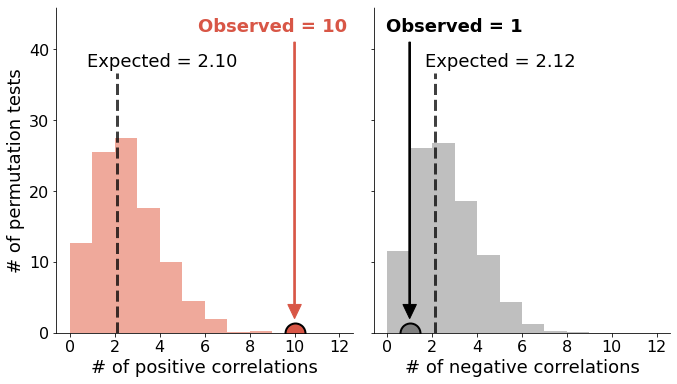

In [37]:
#for fig.4b
#Delta loss 10 1 82
# Omicron loss 11 0 95
# Delta increase 7 4 66
# Omicron increase 4 2 61
colors = cmr.take_cmap_colors('coolwarm', 20, return_fmt='hex')
    
d_loss = pd.read_csv('top_Delta_loss_permutation1000_allZeros.csv', index_col = False)
fig, axs = plt.subplots(1,2,figsize = (11,6), sharey=True, sharex=True)
plt.xticks([0,2,4,6,8,10,12,14])
sns.histplot(d_loss['plus'], kde=False, bins=np.linspace(0, 12, 13), color=colors[16], alpha=0.6,# stat='density', 
                     label='Increased binding',stat = 'percent',ec = None, ax = axs[0])
exp_mean = np.mean(d_loss['plus'])
axs[0].plot([exp_mean,exp_mean],
                    [0,36.7], linestyle='--', color = 'black',linewidth=3, alpha = 0.75)
axs[0].text(exp_mean+2, 37, f'Expected = {exp_mean:.2f}', fontsize=18, va="bottom", ha="center")
axs[0].scatter(x=10,y=0, color = colors[17],edgecolor = 'black',linewidths=2,  alpha = 1, s=400)
axs[0].set_ylim(0,46)

plt.xticks([0,2,4,6,8,10,12])
axs[0].tick_params(axis = 'both', labelsize=16)
axs[0].set_xlabel('# of positive correlations', fontsize = 18)
axs[0].set_ylabel('# of permutation tests', fontsize = 18)
axs[0].arrow(10, 41, 0, -37, head_width=0.6, head_length=2, color = colors[17],width=0.07)
axs[0].text(9, 42, f'Observed = {10}', fontsize=18, va="bottom", ha="center", c = colors[17], weight='semibold')
axs[0].spines['right'].set_color('white')
axs[0].spines['top'].set_color('white')

sns.histplot(d_loss['minus'], kde=False, bins=np.linspace(0, 12, 13), color='grey', alpha=0.5,# stat='density', 
                     label='Increased binding', stat = 'percent',ec = None, ax = axs[1])
exp_mean = np.mean(d_loss['minus'])
axs[1].plot([exp_mean,exp_mean],
                    [0,36.7], linestyle='--', color = 'black',linewidth=3, alpha = 0.75)
axs[1].text(exp_mean+2.9, 37, f'Expected = {exp_mean:.2f}', fontsize=18, va="bottom", ha="center")
axs[1].scatter(x=1,y=0, color = 'grey',edgecolor = 'black',linewidths=2,  alpha = 1, s=400)
axs[1].set_ylim(0,46)

plt.xticks([0,2,4,6,8,10,12,14])
axs[1].tick_params(axis = 'both', labelsize=16)
axs[1].set_xlabel('# of negative correlations', fontsize = 18)
axs[1].set_ylabel('# of permutation tests', fontsize = 18)
axs[1].arrow(1, 41, 0, -37, shape = 'full', head_width=0.6, head_length=2, color = 'black',width=0.07)
axs[1].text(3, 42, f'Observed = {1}', fontsize=18, va="bottom", ha="center", c = 'black', weight='semibold')
axs[1].spines['right'].set_color('white')
axs[1].spines['top'].set_color('white')

plt.subplots_adjust(wspace = 0.07)
#plt.savefig('Fig4/Delta_loss_scheme1000.jpg', dpi=300, bbox_inches='tight')

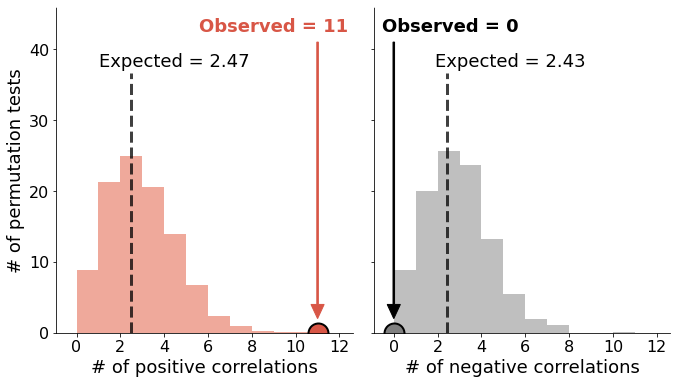

In [30]:
#for fig.4b
#Delta loss 10 1 82
# Omicron loss 11 0 95
# Delta increase 7 4 66
# Omicron increase 4 2 61
colors = cmr.take_cmap_colors('coolwarm', 20, return_fmt='hex')
    
d_loss = pd.read_csv('Fig4/top_Omicron_loss_permutation1000_allZeros.csv', index_col = False) #obtained by permutation test
fig, axs = plt.subplots(1,2,figsize = (11,6), sharey=True, sharex=True)
plt.xticks([0,2,4,6,8,10,12,14])
sns.histplot(d_loss['plus'], kde=False, bins=np.linspace(0, 12, 13), color=colors[16], alpha=0.6,# stat='density', 
                     label='Increased binding', stat = 'percent', ec = None,ax = axs[0])
exp_mean = np.mean(d_loss['plus'])
axs[0].plot([exp_mean,exp_mean],
                    [0,36.7], linestyle='--', color = 'black',linewidth=3, alpha = 0.75)
axs[0].text(exp_mean+2, 37, f'Expected = {exp_mean:.2f}', fontsize=18, va="bottom", ha="center")
axs[0].scatter(x=11,y=0, color = colors[17],edgecolor = 'black',linewidths=2,  alpha = 1, s=400)
axs[0].set_ylim(0,46)

plt.xticks([0,2,4,6,8,10,12,14])
axs[0].tick_params(axis = 'both', labelsize=16)
axs[0].set_xlabel('# of positive correlations', fontsize = 18)
axs[0].set_ylabel('# of permutation tests', fontsize = 18)
axs[0].arrow(11, 41, 0, -37, head_width=0.6, head_length=2, color = colors[17],width=0.07)
axs[0].text(9, 42, f'Observed = {11}', fontsize=18, va="bottom", ha="center", c = colors[17], weight='semibold')
axs[0].spines['right'].set_color('white')
axs[0].spines['top'].set_color('white')


sns.histplot(d_loss['minus'], kde=False, bins=np.linspace(0, 12, 13), color='grey', alpha=0.5,# stat='density', 
                     label='Increased binding',  stat = 'percent',ec = None,ax = axs[1])
exp_mean = np.mean(d_loss['minus'])
axs[1].plot([exp_mean,exp_mean],
                    [0,36.7], linestyle='--', color = 'black',linewidth=3, alpha = 0.75)
axs[1].text(exp_mean+2.9, 37, f'Expected = {exp_mean:.2f}', fontsize=18, va="bottom", ha="center")
axs[1].scatter(x=0,y=0, color = 'grey',edgecolor = 'black',linewidths=2,  alpha = 1, s=400)
axs[1].set_ylim(0,46)

plt.xticks([0,2,4,6,8,10,12])
axs[1].tick_params(axis = 'both', labelsize=16)
axs[1].set_xlabel('# of negative correlations', fontsize = 18)
axs[1].set_ylabel('# of permutation tests', fontsize = 18)
axs[1].arrow(0, 41, 0, -37, shape = 'full', head_width=0.6, head_length=2, color = 'black',width=0.07)
axs[1].text(2.6, 42, f'Observed = {0}', fontsize=18, va="bottom", ha="center", c = 'black', weight='semibold')
axs[1].spines['right'].set_color('white')
axs[1].spines['top'].set_color('white')

plt.subplots_adjust(wspace = 0.07)
plt.savefig('Fig4/Omicron_loss_scheme1000.jpg', dpi=300, bbox_inches='tight')

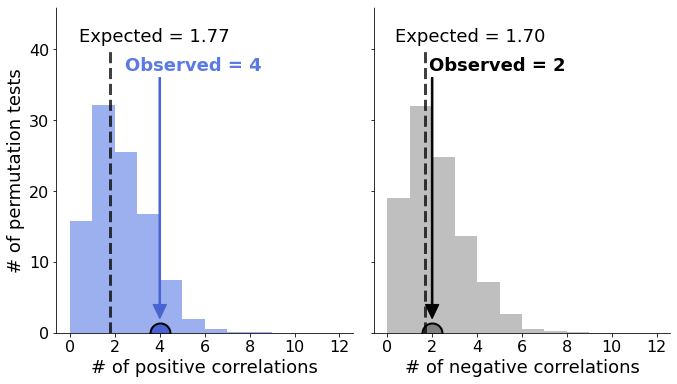

In [32]:
#for fig.4c
#Delta loss 10 1 82
# Omicron loss 11 0 95
# Delta increase 7 4 66
# Omicron increase 4 2 61
colors = cmr.take_cmap_colors('coolwarm', 20, return_fmt='hex')
d_loss = pd.read_csv('Fig4/top_Omicron_increase_permutation1000_allZeros.csv', index_col = False)
fig, axs = plt.subplots(1,2,figsize = (11,6), sharey=True, sharex=True)
plt.xticks([0,2,4,6,8,10,12,14])
sns.histplot(d_loss['plus'], kde=False, bins=np.linspace(0, 12, 13), color=colors[2], alpha=0.6,# stat='density', 
                     label='Increased binding', stat = 'percent',ec=None, ax = axs[0])
exp_mean = np.mean(d_loss['plus'])
axs[0].plot([exp_mean,exp_mean],
                    [0,40], linestyle='--', color = 'black',linewidth=3, alpha = 0.75)
axs[0].text(exp_mean+2, 40.5, f'Expected = {exp_mean:.2f}', fontsize=18, va="bottom", ha="center")
axs[0].scatter(x=4,y=0, color = colors[1],edgecolor = 'black',linewidths=2,  alpha = 1, s=400)
axs[0].set_ylim(0,46)

plt.xticks([0,2,4,6,8,10,12,14])
axs[0].tick_params(axis = 'both', labelsize=16)
axs[0].set_xlabel('# of positive correlations', fontsize = 18)
axs[0].set_ylabel('# of permutation tests', fontsize = 18)
axs[0].arrow(4, 36, 0, -32, head_width=0.6, head_length=2, color = colors[1], width=0.07)
axs[0].text(5.5, 36.5, f'Observed = {4}', fontsize=18, va="bottom", ha="center", c = colors[2], weight='semibold')
axs[0].spines['right'].set_color('white')
axs[0].spines['top'].set_color('white')


sns.histplot(d_loss['minus'], kde=False, bins=np.linspace(0, 12, 13), color='grey', alpha=0.5,# stat='density', 
                     label='Increased binding', stat = 'percent',ec=None, ax = axs[1])
exp_mean = np.mean(d_loss['minus'])
axs[1].plot([exp_mean,exp_mean],
                    [0,40], linestyle='--', color = 'black',linewidth=3, alpha = 0.75)
axs[1].text(exp_mean+2, 40.5, f'Expected = {exp_mean:.2f}', fontsize=18, va="bottom", ha="center")

axs[1].set_ylim(0,46)

plt.xticks([0,2,4,6,8,10,12])
axs[1].tick_params(axis = 'both', labelsize=16)
axs[1].set_xlabel('# of negative correlations', fontsize = 18)
axs[1].set_ylabel('# of permutation tests', fontsize = 18)
axs[1].arrow(2, 36, 0, -32, shape = 'full', head_width=0.6, head_length=2, color = 'black', width=0.07)
axs[1].text(4.9, 36.5, f'Observed = {2}', fontsize=18, va="bottom", ha="center", c = 'black', weight='semibold')
axs[1].scatter(x=2,y=0, color = 'grey',edgecolor = 'black',linewidths=2,  alpha = 1, s=400)
axs[1].spines['right'].set_color('white')
axs[1].spines['top'].set_color('white')


plt.subplots_adjust(wspace = 0.07)
plt.savefig('Fig4/Omicron_increase_scheme1000.jpg', dpi=300, bbox_inches='tight')

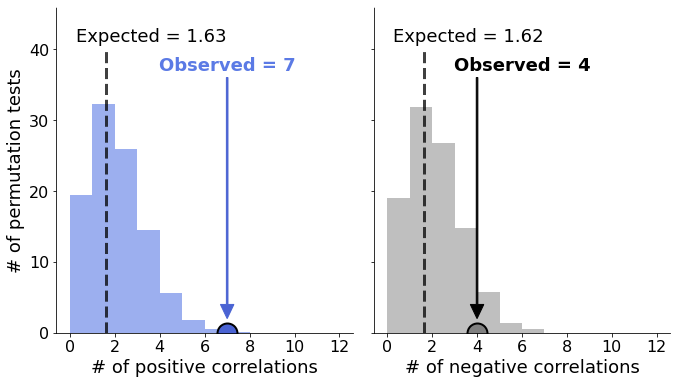

In [33]:
#for fig.4c
#Delta loss 10 1 82
# Omicron loss 11 0 95
# Delta increase 7 4 66
# Omicron increase 4 2 61

colors = cmr.take_cmap_colors('coolwarm', 20, return_fmt='hex')
    
d_loss = pd.read_csv('Fig4/top_Delta_increase_permutation1000_allZeros.csv', index_col = False)
fig, axs = plt.subplots(1,2,figsize = (11,6), sharey=True, sharex=True)
plt.xticks([0,2,4,6,8,10,12,14])
sns.histplot(d_loss['plus'], kde=False, bins=np.linspace(0, 12, 13), color=colors[2], alpha=0.6,# stat='density', 
                     label='Increased binding', stat = 'percent',ec = None, ax = axs[0])
exp_mean = np.mean(d_loss['plus'])
axs[0].plot([exp_mean,exp_mean],
                    [0,40], linestyle='--', color = 'black',linewidth=3, alpha = 0.75)
axs[0].text(exp_mean+2, 40.5, f'Expected = {exp_mean:.2f}', fontsize=18, va="bottom", ha="center")
axs[0].scatter(x=7,y=0, color = colors[1],edgecolor = 'black',linewidths=2,  alpha = 1, s=400)
axs[0].set_ylim(0,46)

plt.xticks([0,2,4,6,8,10,12,14])
axs[0].tick_params(axis = 'both', labelsize=16)
axs[0].set_xlabel('# of positive correlations', fontsize = 18)
axs[0].set_ylabel('# of permutation tests', fontsize = 18)
axs[0].arrow(7, 36, 0, -32, head_width=0.6, head_length=2, color = colors[1], width=0.07)
axs[0].text(7, 36.5, f'Observed = {7}', fontsize=18, va="bottom", ha="center", c = colors[2], weight='semibold')
axs[0].spines['right'].set_color('white')
axs[0].spines['top'].set_color('white')

sns.histplot(d_loss['minus'], kde=False, bins=np.linspace(0, 12, 13), color='grey', alpha=0.5,# stat='density', 
                     label='Increased binding', stat = 'percent',ec = None, ax = axs[1])
exp_mean = np.mean(d_loss['minus'])
axs[1].plot([exp_mean,exp_mean],
                    [0,40], linestyle='--', color = 'black',linewidth=3, alpha = 0.75)
axs[1].text(exp_mean+2, 40.5, f'Expected = {exp_mean:.2f}', fontsize=18, va="bottom", ha="center")
axs[1].scatter(x=4,y=0, color = 'grey',edgecolor = 'black',linewidths=2,  alpha = 1, s=400)
axs[1].set_ylim(0,46)

plt.xticks([0,2,4,6,8,10,12])
axs[1].tick_params(axis = 'both', labelsize=16)
axs[1].set_xlabel('# of negative correlations', fontsize = 18)
axs[1].set_ylabel('# of permutation tests', fontsize = 18)
axs[1].arrow(4, 36, 0, -32, shape = 'full', head_width=0.6, head_length=2, color = 'black', width=0.07)
axs[1].text(6, 36.5, f'Observed = {4}', fontsize=18, va="bottom", ha="center", c = 'black', weight='semibold')
axs[1].spines['right'].set_color('white')
axs[1].spines['top'].set_color('white')


plt.subplots_adjust(wspace = 0.07)
plt.savefig('Fig4/Delta_increase_scheme1000.jpg', dpi=300, bbox_inches='tight')